In [12]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [22]:
data = np.sin(np.linspace(0, 20, 100)).reshape(-1, 1)
print(data)

[[ 0.        ]
 [ 0.20064886]
 [ 0.39313661]
 [ 0.56963411]
 [ 0.72296256]
 [ 0.84688556]
 [ 0.93636273]
 [ 0.98775469]
 [ 0.99897117]
 [ 0.96955595]
 [ 0.90070545]
 [ 0.79522006]
 [ 0.65739025]
 [ 0.49282204]
 [ 0.30820902]
 [ 0.11106004]
 [-0.09060615]
 [-0.28858706]
 [-0.47483011]
 [-0.64176014]
 [-0.7825875 ]
 [-0.89158426]
 [-0.96431712]
 [-0.99782778]
 [-0.99075324]
 [-0.94338126]
 [-0.85763861]
 [-0.73701276]
 [-0.58640998]
 [-0.41195583]
 [-0.22074597]
 [-0.0205576 ]
 [ 0.18046693]
 [ 0.37415123]
 [ 0.55261747]
 [ 0.7086068 ]
 [ 0.83577457]
 [ 0.92894843]
 [ 0.98433866]
 [ 0.99969234]
 [ 0.97438499]
 [ 0.90944594]
 [ 0.8075165 ]
 [ 0.6727425 ]
 [ 0.51060568]
 [ 0.32770071]
 [ 0.13146699]
 [-0.07011396]
 [-0.26884313]
 [-0.45663749]
 [-0.62585878]
 [-0.76962418]
 [-0.88208623]
 [-0.95867071]
 [-0.99626264]
 [-0.99333304]
 [-0.95000106]
 [-0.86802917]
 [-0.75075145]
 [-0.60293801]
 [-0.43060093]
 [-0.24074979]
 [-0.0411065 ]
 [ 0.16020873]
 [ 0.35500771]
 [ 0.53536727]
 [ 0.69395

In [14]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [15]:
# Create sequences for training
# We'll use a sequence of `look_back` values to predict the next value
look_back = 10  # Number of previous time steps to consider
X, y = [], []
for i in range(len(data_scaled) - look_back):
   X.append(data_scaled[i:(i + look_back), 0])
   y.append(data_scaled[i + look_back, 0])
X, y = np.array(X), np.array(y)

In [16]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [17]:
# 2. Build the LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1))) # 50 LSTM units
model.add(Dense(1)) # Output layer for predicting a single value
model.compile(optimizer='adam', loss='mse')

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# temporal split
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=100, batch_size=16,
         validation_data=(X_val, y_val), callbacks=[es], shuffle=False)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.3573 - val_loss: 0.2076
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2744 - val_loss: 0.1745
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2021 - val_loss: 0.1452
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1409 - val_loss: 0.1210
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0999 - val_loss: 0.1075
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0886 - val_loss: 0.1021
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0877 - val_loss: 0.0977
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0825 - val_loss: 0.0942
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0781 - val_loss: 0.0917
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0757 - val_loss: 0.0895
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0737 - val_loss: 0.0868
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0711 - val_lo

In [19]:
last_sequence = data_scaled[-look_back:].reshape(1, look_back, 1)
pred_scaled = model.predict(last_sequence, verbose=0)
predicted_value = scaler.inverse_transform(pred_scaled)[0,0]

In [20]:
future_steps = 10
current = last_sequence.copy()
future_preds = []
for _ in range(future_steps):
   next_scaled = model.predict(current, verbose=0)
   future_preds.append(scaler.inverse_transform(next_scaled)[0,0])
   current = np.concatenate([current[:, 1:, :], next_scaled.reshape(1, 1, 1)], axis=1)


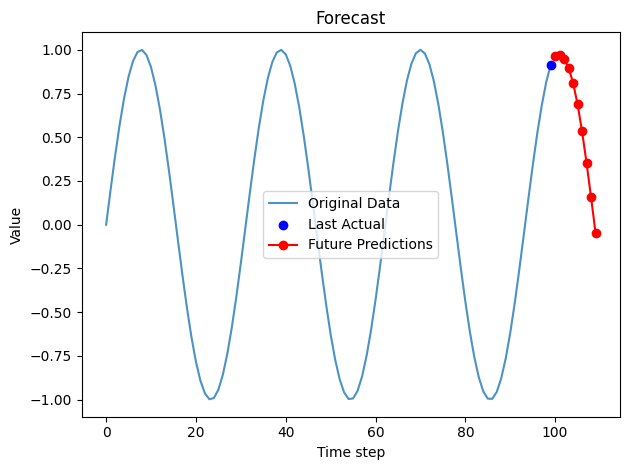

In [21]:
import matplotlib.pyplot as plt
last_idx = len(data) - 1
plt.plot(np.arange(len(data)), data, label='Original Data', alpha=0.8)
plt.scatter(last_idx, data[last_idx], color='blue', label='Last Actual', zorder=5)
future_x = np.arange(last_idx + 1, last_idx + 1 + len(future_preds))
plt.plot(future_x, future_preds, 'ro-', label='Future Predictions')
plt.legend(); plt.xlabel('Time step'); plt.ylabel('Value'); plt.title('Forecast')
plt.tight_layout(); plt.show()